### User Profiling and Segmentation

Bu linkteki datayı kullanarak segmenteleme projesini karşılaştırp kendi kümeleme kodlarımızı oluşturacağız. "https://amanxai.com/2024/02/26/user-profiling-and-segmentation-using-python/"

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/korpionn/user-profiling-and-segmentation/User Profiling and Segmentation.csv


In [2]:
import pandas as pd
pd.set_option("display.max_columns", 100)
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from yellowbrick.cluster import KElbowVisualizer

In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/korpionn/user-profiling-and-segmentation/User Profiling and Segmentation.csv",
    encoding="latin1"
)

df.head()

,User ID,Age,Gender,Location,Language,Education Level,Likes and Reactions,Followed Accounts,Device Usage,Time Spent Online (hrs/weekday),Time Spent Online (hrs/weekend),Click-Through Rates (CTR),Conversion Rates,Ad Interaction Time (sec),Income Level,Top Interests
0,1,25-34,Female,Suburban,Hindi,Technical,5640,190,Mobile Only,4.5,1.7,0.193,0.067,25,20k-40k,Digital Marketing
1,2,65+,Male,Urban,Hindi,PhD,9501,375,Tablet,0.5,7.7,0.114,0.044,68,0-20k,Data Science
2,3,45-54,Female,Suburban,Spanish,Technical,4775,187,Mobile Only,4.5,5.6,0.153,0.095,80,60k-80k,Fitness and Wellness
3,4,35-44,Female,Rural,Spanish,PhD,9182,152,Desktop Only,3.1,4.2,0.093,0.061,65,100k+,"Gaming, DIY Crafts"
4,5,25-34,Female,Urban,English,Technical,6848,371,Mobile Only,2.0,3.8,0.175,0.022,99,20k-40k,"Fitness and Wellness, Investing and Finance, G..."


In [4]:
df.isnull().sum() # dataset de boş veri yok. 

User ID                            0
Age                                0
Gender                             0
Location                           0
Language                           0
Education Level                    0
Likes and Reactions                0
Followed Accounts                  0
Device Usage                       0
Time Spent Online (hrs/weekday)    0
Time Spent Online (hrs/weekend)    0
Click-Through Rates (CTR)          0
Conversion Rates                   0
Ad Interaction Time (sec)          0
Income Level                       0
Top Interests                      0
dtype: int64

linteki kodlarda çok detaylı EDa yapılmış.  kilit demografik değişkenler için detaylı grafikler çizilmiş. (key demographic variables (age, gender, education level, and income level))

Ayrıca linkteki kodda hftasonları ve haftaiçleri ekran zamanları detaylı incelenmiş. 

Biz de aşağıda alet kullanım dağılımını göstermek istedik.

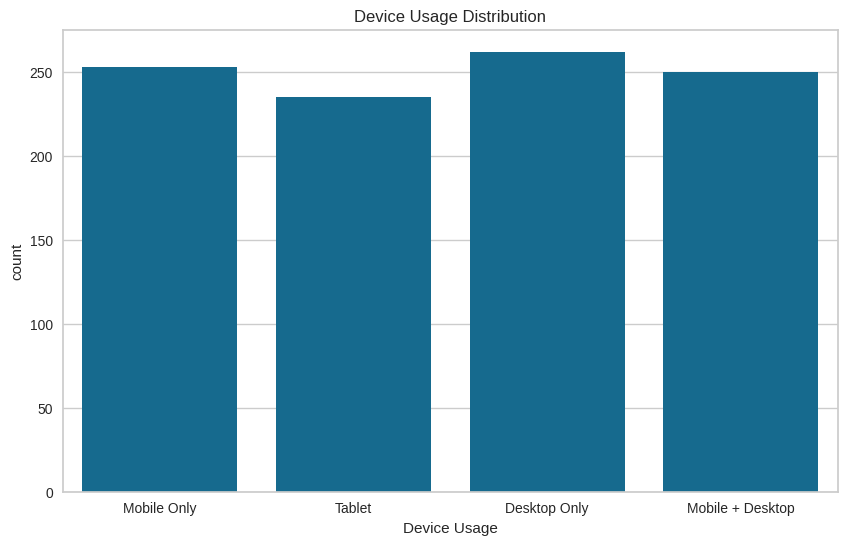

In [5]:
# device usage distribution
plt.figure(figsize=(10,6))
sns.countplot(x=df["Device Usage"])
plt.title("Device Usage Distribution")
plt.show()

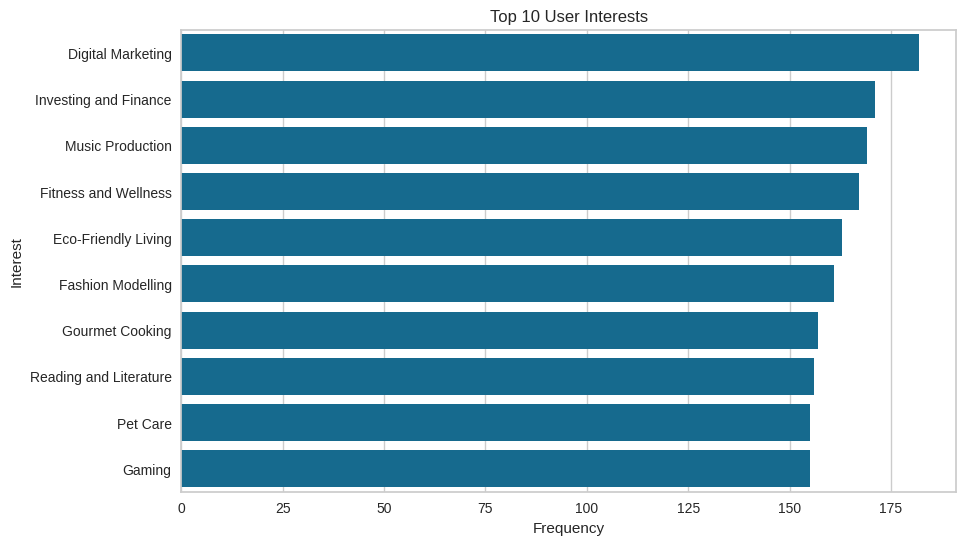

In [6]:
# bazı satırlarda birden fazla alan var, virgülle ayrılmış interestleri parçaladık
interests = df["Top Interests"].str.split(", ")

# explode ile satırlara böldük
interests = interests.explode()

# ilgi alanlarını saydık
top_interests = interests.value_counts().head(10)


plt.figure(figsize=(10,6))
sns.barplot(x=top_interests.values, y=top_interests.index)

plt.title("Top 10 User Interests")
plt.xlabel("Frequency")
plt.ylabel("Interest")

plt.show()

### Model 
Aynı kümelemeyi yapıp karşılaştırmak istedik. 

In [7]:
features = [
    "Age",
    "Gender",
    "Income Level",
    "Time Spent Online (hrs/weekday)",
    "Time Spent Online (hrs/weekend)",
    "Likes and Reactions",
    "Click-Through Rates (CTR)",
]

x = df[features]

In [8]:
x = pd.get_dummies(x, drop_first=True)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

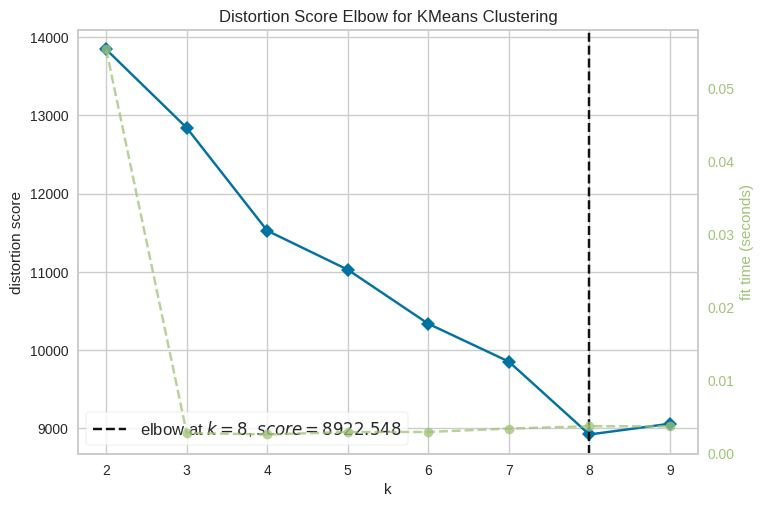

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [10]:
vis=KElbowVisualizer(KMeans(), k=(2,10)) #elbow u gösteren grafik
vis.fit(x_scaled)
vis.show()

Her ne kadar dirsek 8 çıksa da linkteki gibi 5  kümeye ayırılmıştır. 

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42)

labels = kmeans.fit_predict(x_scaled)

df["Cluster"] = labels

In [12]:
df.head()

,User ID,Age,Gender,Location,Language,Education Level,Likes and Reactions,Followed Accounts,Device Usage,Time Spent Online (hrs/weekday),Time Spent Online (hrs/weekend),Click-Through Rates (CTR),Conversion Rates,Ad Interaction Time (sec),Income Level,Top Interests,Cluster
0,1,25-34,Female,Suburban,Hindi,Technical,5640,190,Mobile Only,4.5,1.7,0.193,0.067,25,20k-40k,Digital Marketing,2
1,2,65+,Male,Urban,Hindi,PhD,9501,375,Tablet,0.5,7.7,0.114,0.044,68,0-20k,Data Science,4
2,3,45-54,Female,Suburban,Spanish,Technical,4775,187,Mobile Only,4.5,5.6,0.153,0.095,80,60k-80k,Fitness and Wellness,1
3,4,35-44,Female,Rural,Spanish,PhD,9182,152,Desktop Only,3.1,4.2,0.093,0.061,65,100k+,"Gaming, DIY Crafts",0
4,5,25-34,Female,Urban,English,Technical,6848,371,Mobile Only,2.0,3.8,0.175,0.022,99,20k-40k,"Fitness and Wellness, Investing and Finance, G...",2


<Axes: xlabel='Cluster', ylabel='count'>

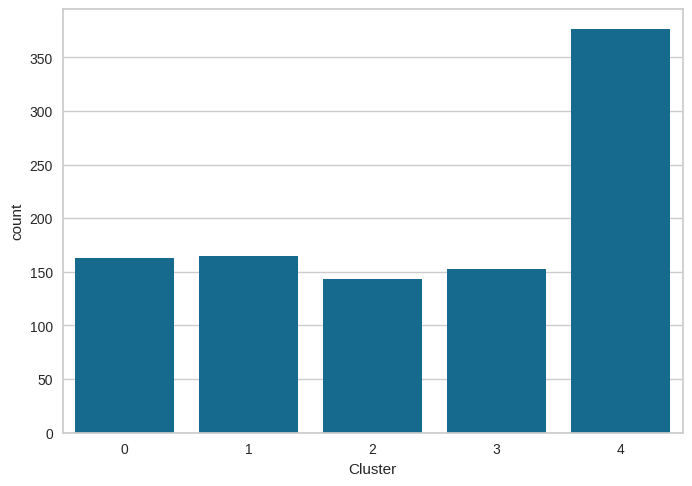

In [13]:
sns.countplot(x=df["Cluster"])

In [14]:
numeric_features = [
    "Time Spent Online (hrs/weekday)",
    "Time Spent Online (hrs/weekend)",
    "Likes and Reactions",
    "Click-Through Rates (CTR)"
]

categorical_features = [
    "Age",
    "Gender",
    "Income Level"
]

cluster_means = df.groupby("Cluster")[numeric_features].mean()

for feature in categorical_features:
    mode_series = df.groupby("Cluster")[feature].agg(lambda x: x.mode()[0])
    cluster_means[feature] = mode_series

print(cluster_means)

         Time Spent Online (hrs/weekday)  Time Spent Online (hrs/weekend)  \
Cluster                                                                     
0                               2.938650                         4.461350   
1                               2.917576                         4.360000   
2                               2.607692                         4.669231   
3                               2.811765                         4.652941   
4                               2.643617                         4.721809   

         Likes and Reactions  Click-Through Rates (CTR)    Age  Gender  \
Cluster                                                                  
0                4802.319018                   0.122840  35-44    Male   
1                5180.860606                   0.120830  45-54  Female   
2                5187.055944                   0.137399  25-34    Male   
3                5107.267974                   0.125124  55-64  Female   
4               

Cluster 0:
Orta yaş (35–44), erkek, orta gelir.
Ortalama etkileşim ve kullanım → dengeli kullanıcılar

Cluster 1:
45–54, kadın, orta gelir.
Beğeni ve etkileşim yüksek → aktif ve ilgili kullanıcılar

Cluster 2:
25–34, erkek, düşük-orta gelir.
CTR en yüksek → reklama en duyarlı kullanıcılar

Cluster 3:
55–64, kadın, orta gelir.
Online süresi yüksek ama etkileşim düşük → pasif kullanıcılar

Cluster 4:
25–34, kadın, yüksek gelir.
Seçici etkileşim → premium kullanıcılar

Genel Sonuç

Kullanıcılar yaş, cinsiyet, gelir ve etkileşim davranışlarına göre 5 farklı gruba ayrılmıştır.
Sayısal farklar küçük olsa da kategorik değişkenler sayesinde anlamlı segmentler elde edilmiştir.
Bu segmentler, hedefli pazarlama stratejileri geliştirmek için kullanılabilir. Bu bulgular linkteki bulgularla tam uyumlu değildir. gelir ve cinsiyet tam aynı çıkmamıştır. 

In [15]:
import pickle

model_data = {
    "kmeans": kmeans,
    "scaler": scaler,
    "columns": x.columns.tolist()
}

with open("user_segmentation.pkl", "wb") as f:
    pickle.dump(model_data, f)

In [1]:
# https://huggingface.co/spaces/fatmasy/UserProfilingandSegmentation